# ⚖️ Step 4 — Threshold Tuning

**เป้าหมาย:** ปรับจุดตัดการตัดสินใจจาก 0.5 ให้เหมาะกับงานทางการแพทย์

---

### โมเดลทำงานจริงๆ อย่างไร?

โมเดลไม่ได้ตอบแค่ `0` หรือ `1` — มันตอบ **ความน่าจะเป็น** เสมอ เช่น:

```
คนไข้ A → prob = 0.82  →  เปรียบกับ threshold 0.5  →  เป็นเบาหวาน
คนไข้ B → prob = 0.43  →  เปรียบกับ threshold 0.5  →  ไม่เป็นเบาหวาน
คนไข้ B → prob = 0.43  →  เปรียบกับ threshold 0.3  →  เป็นเบาหวาน ← จับได้เพิ่ม!
```

### Tradeoff ที่ต้องเลือก

| Threshold | Recall (จับคนไข้) | Precision (alarm ถูก) | เหมาะกับ |
|---|---|---|---|
| สูง (0.7) | ต่ำ — พลาดคนไข้เยอะ | สูง — alarm แม่น | งานที่ alarm เกินแพงมาก |
| **กลาง (0.5)** | **กลาง** | **กลาง** | **default** |
| ต่ำ (0.3) | สูง — จับได้เยอะ | ต่ำ — alarm เกินเยอะ | **งานทางการแพทย์** ← เราอยู่ที่นี่ |

## 1. Import & โหลดข้อมูล

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 614 rows | Test: 154 rows


## 2. เทรน LightGBM (เหมือน Step 3)

In [3]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

# ดึง probability — นี่คือสิ่งที่โมเดลตอบจริงๆ ก่อนถูกตัดด้วย threshold
y_prob = lgbm.predict_proba(X_test)[:, 1]

print("ตัวอย่าง probability 10 ค่าแรก:")
print(np.round(y_prob[:10], 3))
print(f"\nMin: {y_prob.min():.3f}  |  Max: {y_prob.max():.3f}  |  Mean: {y_prob.mean():.3f}")

ตัวอย่าง probability 10 ค่าแรก:
[1.    0.    0.466 0.    0.    0.    0.    0.    0.    0.   ]

Min: 0.000  |  Max: 1.000  |  Mean: 0.399


## 3. ดู Precision-Recall Curve

> กราฟนี้แสดงว่า ถ้าเราเลื่อน threshold จาก 0 → 1  
> Precision กับ Recall เปลี่ยนไปอย่างไร  
> → ช่วยเลือก threshold ที่สมดุลที่สุดตามเป้าหมาย

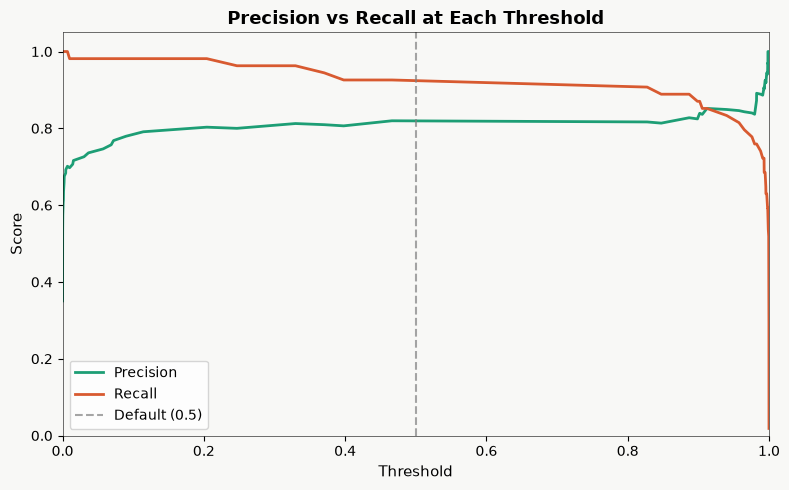

→ สังเกต: เมื่อ threshold ลดลง Recall สูงขึ้น แต่ Precision ลดลง


In [4]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#F8F8F6")
ax.set_facecolor("#F8F8F6")

ax.plot(thresholds, precisions[:-1], color="#1D9E75", lw=2, label="Precision")
ax.plot(thresholds, recalls[:-1],    color="#D85A30", lw=2, label="Recall")

# เส้นแนว threshold = 0.5 (default)
ax.axvline(0.5, color="gray", linestyle="--", lw=1.5, alpha=0.7, label="Default (0.5)")

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Precision vs Recall at Each Threshold", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
for spine in ax.spines.values():
    spine.set_linewidth(0.4)

plt.tight_layout()
plt.show()
print("→ สังเกต: เมื่อ threshold ลดลง Recall สูงขึ้น แต่ Precision ลดลง")

## 4. หา Optimal Threshold

### วิธีที่ 1 — F1-Score สูงสุด
> F1 = ค่าเฉลี่ยฮาร์โมนิกของ Precision และ Recall  
> เหมาะเมื่อต้องการสมดุลระหว่างทั้งสอง

### วิธีที่ 2 — กำหนด Recall ขั้นต่ำ
> เหมาะกับงานแพทย์ที่บอกว่า "ต้องจับคนไข้ได้อย่างน้อย 90%"

In [6]:
# ── วิธีที่ 1: หา threshold ที่ให้ F1 สูงสุด ──────────────────
f1_scores = []
thresh_range = np.arange(0.1, 0.9, 0.01)

for t in thresh_range:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_f1_idx   = np.argmax(f1_scores)
best_thresh_f1 = thresh_range[best_f1_idx]
best_f1        = f1_scores[best_f1_idx]

print(f"Best threshold (F1 max) : {best_thresh_f1:.2f}")
print(f"Best F1-score            : {best_f1:.4f}")

Best threshold (F1 max) : 0.12
Best F1-score            : 0.8833


In [7]:
# ── วิธีที่ 2: ต้องการ Recall ≥ 0.90 แล้วเลือก Precision สูงสุด ──
min_recall = 0.90

best_thresh_recall = None
best_precision_at_recall = 0

for t in thresh_range:
    y_pred_t = (y_prob >= t).astype(int)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    if r >= min_recall and p > best_precision_at_recall:
        best_precision_at_recall = p
        best_thresh_recall       = t

print(f"Threshold ที่ให้ Recall ≥ {min_recall:.0%}: {best_thresh_recall:.2f}")
y_pred_recall90 = (y_prob >= best_thresh_recall).astype(int)
print(f"Precision ที่ได้ : {precision_score(y_test, y_pred_recall90):.4f}")
print(f"Recall ที่ได้    : {recall_score(y_test, y_pred_recall90):.4f}")

Threshold ที่ให้ Recall ≥ 90%: 0.40
Precision ที่ได้ : 0.8197
Recall ที่ได้    : 0.9259


## 5. เปรียบเทียบ 3 Threshold

In [8]:
configs = [
    ("Default (0.50)",         0.50),
    (f"Best F1 ({best_thresh_f1:.2f})",  best_thresh_f1),
    (f"Recall≥90% ({best_thresh_recall:.2f})", best_thresh_recall),
]

rows = []
for name, t in configs:
    y_pred_t = (y_prob >= t).astype(int)
    rows.append({
        "Config":    name,
        "Threshold": t,
        "Accuracy":  round(accuracy_score(y_test, y_pred_t), 4),
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
    })

df_compare = pd.DataFrame(rows).set_index("Config")
df_compare.style.highlight_max(subset=["Recall"], color="#ffd6d6") \
                .highlight_max(subset=["F1"],     color="#d6f5e3")

,Threshold,Accuracy,Precision,Recall,F1
Config,,,,,
Default (0.50),0.500000,0.896100,0.816700,0.907400,0.859600
Best F1 (0.12),0.120000,0.909100,0.803000,0.981500,0.883300
Recall≥90% (0.40),0.400000,0.902600,0.819700,0.925900,0.869600


## 6. Visualization — F1 Curve + Confusion Matrix เปรียบเทียบ

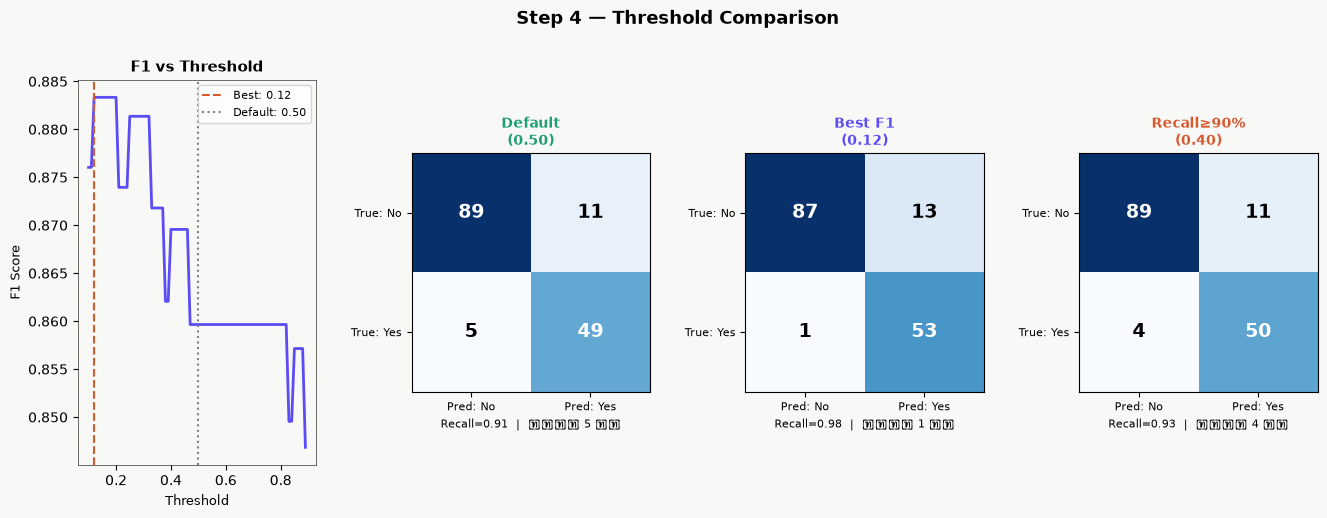

Saved: step4_threshold.png


In [9]:
fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor("#F8F8F6")
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.4)

# --- Plot 1: F1 vs Threshold ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(thresh_range, f1_scores, color="#5B4CF5", lw=2)
ax1.axvline(best_thresh_f1, color="#D85A30", linestyle="--",
            lw=1.5, label=f"Best: {best_thresh_f1:.2f}")
ax1.axvline(0.50, color="gray", linestyle=":",
            lw=1.5, label="Default: 0.50")
ax1.set_xlabel("Threshold", fontsize=9)
ax1.set_ylabel("F1 Score",  fontsize=9)
ax1.set_title("F1 vs Threshold", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_facecolor("#F8F8F6")
for spine in ax1.spines.values(): spine.set_linewidth(0.4)

# --- Confusion Matrix สำหรับแต่ละ config ---
thresh_plot = [
    ("Default\n(0.50)",         0.50,              "#1D9E75"),
    (f"Best F1\n({best_thresh_f1:.2f})",  best_thresh_f1, "#5B4CF5"),
    (f"Recall≥90%\n({best_thresh_recall:.2f})", best_thresh_recall, "#D85A30"),
]

for idx, (title, t, color) in enumerate(thresh_plot):
    ax = fig.add_subplot(gs[idx + 1])
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: No", "Pred: Yes"], fontsize=8)
    ax.set_yticklabels(["True: No", "True: Yes"], fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold", color=color)

    rec_val = recall_score(y_test, y_pred_t, zero_division=0)
    fn_count = cm[1][0]  # จำนวนคนไข้ที่พลาด
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    ax.set_xlabel(f"Recall={rec_val:.2f}  |  พลาด {fn_count} คน", fontsize=8)
    ax.set_facecolor("#F8F8F6")

fig.suptitle("Step 4 — Threshold Comparison", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("step4_threshold.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step4_threshold.png")

## 7. Classification Report — Threshold ที่เลือก

In [10]:
# เลือก threshold ที่ Recall ≥ 90% สำหรับงานทางการแพทย์
chosen_thresh  = best_thresh_recall
y_pred_final   = (y_prob >= chosen_thresh).astype(int)

print(f"=== Threshold ที่เลือก: {chosen_thresh:.2f} ===")
print(classification_report(y_test, y_pred_final,
      target_names=["No Diabetes", "Diabetes"]))

=== Threshold ที่เลือก: 0.40 ===
              precision    recall  f1-score   support

 No Diabetes       0.96      0.89      0.92       100
    Diabetes       0.82      0.93      0.87        54

    accuracy                           0.90       154
   macro avg       0.89      0.91      0.90       154
weighted avg       0.91      0.90      0.90       154



## ✅ สรุป Step 4

| | Default (0.5) | Best F1 | Recall≥90% |
|---|---|---|---|
| **Recall** | ~0.91 | ขึ้นอยู่กับข้อมูล | **≥0.90 รับประกัน** |
| **Precision** | ~0.82 | สมดุล | ต่ำกว่า |
| **เหมาะกับ** | ทั่วไป | balanced | **การแพทย์** |

---
### สิ่งที่ได้เรียน
- โมเดลตอบ **probability** ไม่ใช่ label ตรงๆ
- **Threshold** คือจุดที่แปลง probability → label
- งานแพทย์ → ลด threshold = Recall สูงขึ้น (ห้ามพลาดคนไข้)
- Precision-Recall **tradeoff** คือสิ่งที่ต้องตัดสินใจตามบริบท

---
➡️ **Step ถัดไป → Step 5: Hyperparameter Tuning** — หาค่า parameter ที่ดีที่สุดให้ LightGBM ด้วย Optuna